In [45]:
import pandas as pd
import matplotlib.pyplot as plt


This notebook is for exploration and analysis purposes only. Valuable findings of this notebook have been structured within the Project Report pdf document.

In [46]:
df = pd.read_csv("Books.csv")

In [47]:
df

,Title,Subject code,Author,Grade,Type,Edition,Price
0,O Leve Yearly Unsolved English Language Paper ...,1123,NaN,O Level,Yearly Unsolved,S15-W19,1500
1,O Level Add Math Notes by Rafique Akhtar,4037,Rafique Akhtar,O Level,Notes,2019-2020,1350
2,O Level Biology Notes by Abid Aziz,5090,Abid Aziz,O Level,Notes,2024-2025,1500
3,O Level Biology Notes by Dr. Sadia Khalid,5090,Dr. Sadia Khalid,O Level,Notes,2023-2025,1550
4,O Level Biology Notes by Hamza Fayyaz,NaN,Hamza Fayyaz,O Level,Notes,2021 Edition,1350
...,...,...,...,...,...,...,...
292,IGCSE Unsolved Topical Maths Paper 2 (2025-202...,0580,NaN,O Level,Unsolved Topical,S17-W24,2050
293,IGCSE Unsolved Topical Maths Paper 4 (2025-202...,0580,NaN,O Level,Unsolved Topical,S17-W24,3050
294,IGCSE Unsolved Topical Physics Paper 2 (Mcqs) ...,NaN,NaN,O Level,Unsolved Topical,S17-W24,1800
295,IGCSE Unsolved Topical Physics Paper 4 (Theory...,0625,NaN,O Level,Unsolved Topical,S17-W24,2350


In [48]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Title         297 non-null    str  
 1   Subject code  279 non-null    str  
 2   Author        62 non-null     str  
 3   Grade         297 non-null    str  
 4   Type          290 non-null    str  
 5   Edition       288 non-null    str  
 6   Price         297 non-null    int64
dtypes: int64(1), str(6)
memory usage: 16.4 KB


In [49]:
df["Subject code"] = df["Subject code"].fillna("Unknown")
df["Author"] = df["Author"].fillna("No author")
df["Type"] = df["Type"].fillna("Unknown")
df["Edition"] = df["Edition"].fillna("Unknown")


In [50]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Title         297 non-null    str  
 1   Subject code  297 non-null    str  
 2   Author        297 non-null    str  
 3   Grade         297 non-null    str  
 4   Type          297 non-null    str  
 5   Edition       297 non-null    str  
 6   Price         297 non-null    int64
dtypes: int64(1), str(6)
memory usage: 16.4 KB


In [51]:
df.loc[df["Title"].str.contains("IGCSE", case=False, na=False),"Grade"] = "IGCSE"

In [52]:
total_books_per_subject = df.groupby("Subject code").size().sort_values(ascending=False)
total_books_per_subject

Subject code
Unknown    18
2059       13
9702       12
5090       11
9700       11
           ..
0539        1
2069        1
9383        1
7110        1
9110        1
Length: 66, dtype: int64

In [53]:
df[df["Subject code"] == "Unknown"]["Title"]

4                  O Level Biology Notes by Hamza Fayyaz
137            A Level Computer P1 Notes by Navid Saqib.
138    A Level Computer P2 (python) Notes by Navid Saqib
139       A Level Computer P2 (V.B) Notes by Navid Saqib
140        A Level Computer P4 (VB) Notes by Navid Saqib
216         AL Maths Notes (M1) Paper 4 By Rafeeq Akhtar
217         AL Maths Notes (S1) Paper 5 By Rafeeq Akhtar
218              AL Maths Notes Paper 1 By Rafeeq Akhtar
219              AL Maths Notes Paper 3 By Rafeeq Akhtar
228    AL Unsolved Topical Chemistry P1 (2025-2026 Ed...
235     AL Unsolved Topical Maths P1 (2025-2026 Edition)
236     AL Unsolved Topical Maths P3 (2025-2026 Edition)
237    AL Unsolved Topical Maths P4 (M1) (2025-2026 E...
238    AL Unsolved Topical Maths P5 (S1) (2025-2026 E...
244               AS Level Biology Notes by Hamza Fayyaz
287    IGCSE Unsolved Topical Biology Paper 4 (Theory...
288    IGCSE Unsolved Topical Biology Paper 6 (ATP) (...
294    IGCSE Unsolved Topical P

In [54]:
df["Grade"] = df["Grade"].replace("Igcse","IGCSE")
df["Grade"].unique()

<StringArray>
['O Level', 'A Level', 'IGCSE']
Length: 3, dtype: str

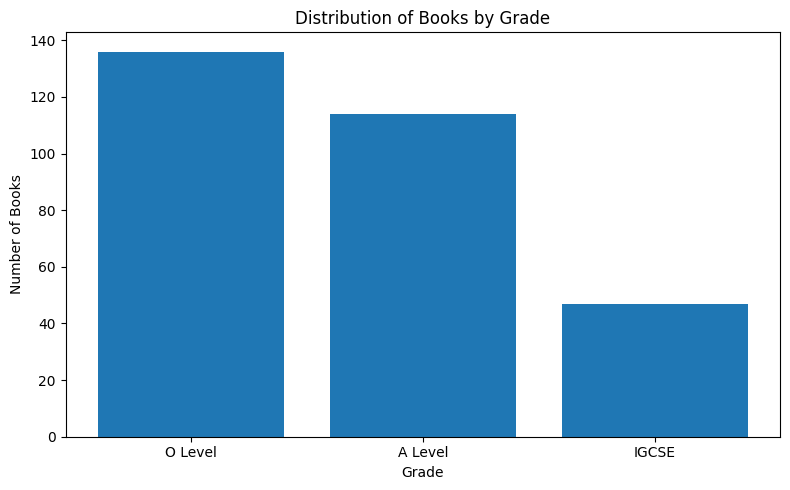

In [55]:
grade_counts = df["Grade"].value_counts().reset_index()

grade_counts.columns = ["Grade", "Book Count"]

plt.figure(figsize=(8, 5))
plt.bar(grade_counts["Grade"], grade_counts["Book Count"])

plt.xlabel("Grade")
plt.ylabel("Number of Books")
plt.title("Distribution of Books by Grade")

plt.tight_layout()
plt.show()

In [56]:
df["Type"].unique()

<StringArray>
['Yearly Unsolved', 'Notes', 'Unsolved Topical', 'Unknown',
 'Unsolved Topicals']
Length: 5, dtype: str

In [57]:
df["Type"] = df["Type"].replace({
    "Yearlyly Unsolved": "Yearly Unsolved",
    "Unsolved Topicals": "Unsolved Topical"
    })
df["Type"].unique()

<StringArray>
['Yearly Unsolved', 'Notes', 'Unsolved Topical', 'Unknown']
Length: 4, dtype: str

In [58]:
df.loc[df["Title"].str.contains("Topical", case=False, na=False),"Type"] = "Unsolved Topical"
df.loc[df["Title"].str.contains("Yearly", case=False, na=False),"Type"] = "Yearly Unsolved"
df.loc[df["Title"].str.contains("Notes", case=False, na=False),"Type"] = "Notes"
df["Type"].unique()

<StringArray>
['Yearly Unsolved', 'Notes', 'Unsolved Topical']
Length: 3, dtype: str

In [59]:
df

,Title,Subject code,Author,Grade,Type,Edition,Price
0,O Leve Yearly Unsolved English Language Paper ...,1123,No author,O Level,Yearly Unsolved,S15-W19,1500
1,O Level Add Math Notes by Rafique Akhtar,4037,Rafique Akhtar,O Level,Notes,2019-2020,1350
2,O Level Biology Notes by Abid Aziz,5090,Abid Aziz,O Level,Notes,2024-2025,1500
3,O Level Biology Notes by Dr. Sadia Khalid,5090,Dr. Sadia Khalid,O Level,Notes,2023-2025,1550
4,O Level Biology Notes by Hamza Fayyaz,Unknown,Hamza Fayyaz,O Level,Notes,2021 Edition,1350
...,...,...,...,...,...,...,...
292,IGCSE Unsolved Topical Maths Paper 2 (2025-202...,0580,No author,IGCSE,Unsolved Topical,S17-W24,2050
293,IGCSE Unsolved Topical Maths Paper 4 (2025-202...,0580,No author,IGCSE,Unsolved Topical,S17-W24,3050
294,IGCSE Unsolved Topical Physics Paper 2 (Mcqs) ...,Unknown,No author,IGCSE,Unsolved Topical,S17-W24,1800
295,IGCSE Unsolved Topical Physics Paper 4 (Theory...,0625,No author,IGCSE,Unsolved Topical,S17-W24,2350


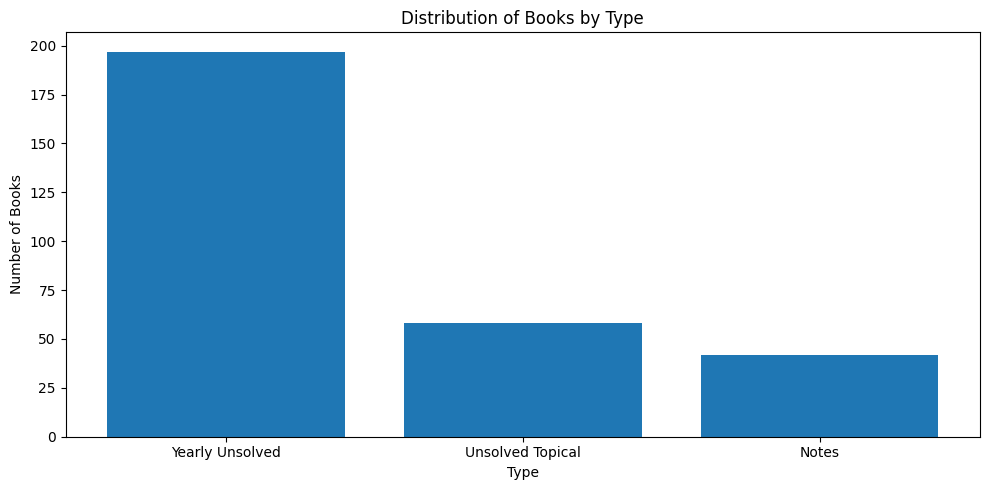

In [60]:
type_counts = df["Type"].value_counts().reset_index()
type_counts.columns = ["Type", "Book Count"]

plt.figure(figsize=(10, 5))
plt.bar(type_counts["Type"], type_counts["Book Count"])
plt.xlabel("Type")
plt.ylabel("Number of Books")
plt.title("Distribution of Books by Type")
plt.tight_layout()
plt.show()

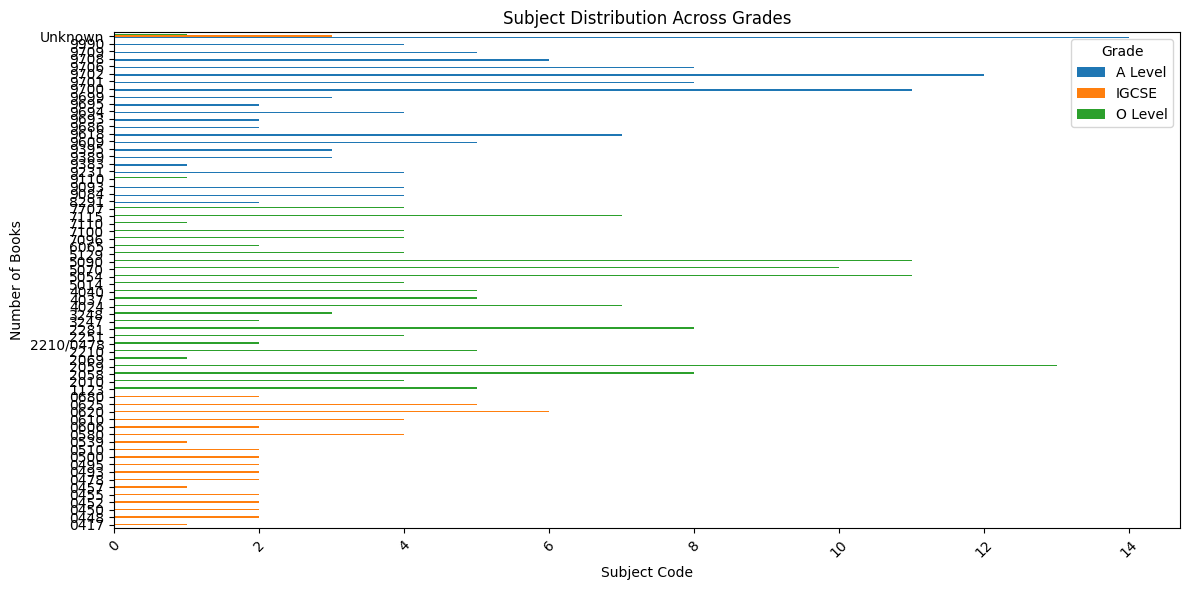

In [61]:
subject_grade = df.groupby(["Grade", "Subject code"]).size().reset_index(name="Book Count")
pivot_subject_grade = subject_grade.pivot(
    index="Subject code",
    columns="Grade",
    values="Book Count"
).fillna(0)
pivot_subject_grade.plot(kind="barh", figsize=(12, 6))
plt.xlabel("Subject Code")
plt.ylabel("Number of Books")
plt.title("Subject Distribution Across Grades")
plt.xticks(rotation=45)
plt.legend(title="Grade")
plt.tight_layout()
plt.show()

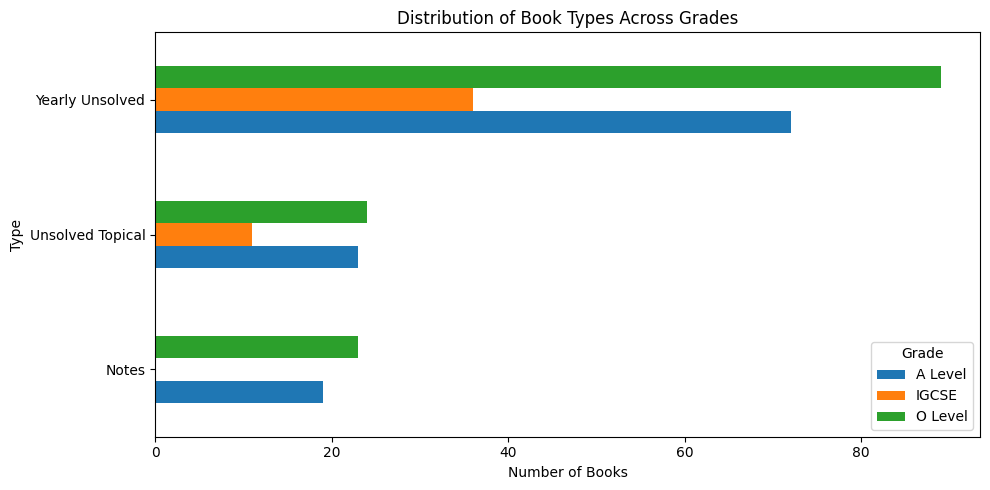

In [62]:
type_grade = df.groupby(["Grade", "Type"]).size().reset_index(name="Book Count")
pivot_type_grade = type_grade.pivot(
    index="Type",
    columns="Grade",
    values="Book Count"
).fillna(0)
pivot_type_grade.plot(kind="barh", figsize=(10, 5))
plt.ylabel("Type")
plt.xlabel("Number of Books")
plt.title("Distribution of Book Types Across Grades")
plt.legend(title="Grade")

plt.tight_layout()
plt.show()


In [63]:
df.groupby("Grade")["Price"].mean()

Grade
A Level    1659.210526
IGCSE      1941.489362
O Level    1294.485294
Name: Price, dtype: float64

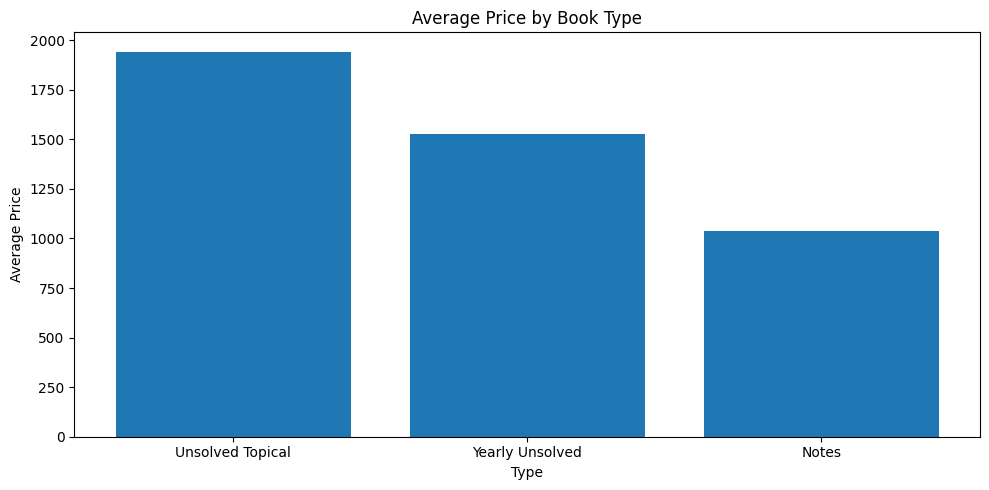

In [64]:
type_price = df.groupby("Type")["Price"].mean().sort_values(ascending=False)
plt.figure(figsize=(10, 5))
plt.bar(type_price.index, type_price.values)

plt.xlabel("Type")
plt.ylabel("Average Price")
plt.title("Average Price by Book Type")

plt.tight_layout()
plt.show()

In [65]:
subject_table = df["Subject code"].value_counts().reset_index()
subject_table.columns = ["Subject code", "Number of Books"]
subject_table.tail(10)

,Subject code,Number of Books
56,0493,2
57,0448,2
58,0495,2
59,7110,1
60,9110,1
61,2069,1
62,9383,1
63,0457,1
64,0417,1
65,0539,1


In [66]:
clean_df = df[df["Subject code"] != "Unknown"]
o_df = clean_df[clean_df["Grade"] == "O Level"]
olevel_table = o_df["Subject code"].value_counts().reset_index()
olevel_table.columns = ["Subject code", "Number of Books"]

olevel_table.head(10)

,Subject code,Number of Books
0,2059,13
1,5090,11
2,5054,11
3,5070,10
4,2281,8
5,2058,8
6,7115,7
7,4024,7
8,1123,5
9,4037,5


In [67]:
clean_df = df[df["Subject code"] != "Unknown"]
a_df = clean_df[clean_df["Grade"] == "A Level"]
alevel_table = a_df["Subject code"].value_counts().reset_index()
alevel_table.columns = ["Subject code", "Number of Books"]

alevel_table.head(10)

,Subject code,Number of Books
0,9702,12
1,9700,11
2,9706,8
3,9701,8
4,9618,7
5,9708,6
6,9609,5
7,9709,5
8,9093,4
9,9231,4


In [68]:
clean_df = df[df["Subject code"] != "Unknown"]
i_df = clean_df[clean_df["Grade"] == "IGCSE"]
igcse_table = i_df["Subject code"].value_counts().reset_index()
igcse_table.columns = ["Subject code", "Number of Books"]

igcse_table.head(10)

,Subject code,Number of Books
0,0620,6
1,0625,5
2,0610,4
3,0580,4
4,0452,2
5,0606,2
6,0450,2
7,0478,2
8,0455,2
9,0500,2


In [69]:
df.groupby("Grade")["Price"].describe()

,count,mean,std,min,25%,50%,75%,max
Grade,,,,,,,,
A Level,114.0,1659.210526,721.18897,500.0,1050.0,1600.0,2200.0,3350.0
IGCSE,47.0,1941.489362,598.75951,450.0,1550.0,1950.0,2400.0,3250.0
O Level,136.0,1294.485294,471.47023,450.0,850.0,1250.0,1600.0,2400.0


In [70]:
df.groupby("Type")["Price"].describe()

,count,mean,std,min,25%,50%,75%,max
Type,,,,,,,,
Notes,42.0,1035.714286,406.394875,450.0,750.0,950.0,1200.0,2500.0
Unsolved Topical,58.0,1942.241379,532.850801,950.0,1600.0,1950.0,2300.0,3050.0
Yearly Unsolved,197.0,1524.365482,637.269549,450.0,1000.0,1500.0,1900.0,3350.0


In [71]:
df[df["Grade"] == "IGCSE"]

,Title,Subject code,Author,Grade,Type,Edition,Price
250,(IGCSE) Yearly Unsolved Accounting Paper 1 (S2...,0452,No author,IGCSE,Yearly Unsolved,S21-W25,850
251,(IGCSE) Yearly Unsolved Accounting Paper 2 (S2...,0452,No author,IGCSE,Yearly Unsolved,S21-W25,2100
252,(IGCSE) Yearly Unsolved Add Maths Paper 1 (S21...,0606,No author,IGCSE,Yearly Unsolved,S21-W25,2150
253,(IGCSE) Yearly Unsolved Add Maths Paper 2 (S21...,0606,No author,IGCSE,Yearly Unsolved,S21-W25,2200
254,(IGCSE) Yearly Unsolved Biology Paper 2 (S21-W25),0610,No author,IGCSE,Yearly Unsolved,S21-W25,1550
255,(IGCSE) Yearly Unsolved Biology Paper 4 (S21-W25),0610,No author,IGCSE,Yearly Unsolved,S21-W25,2550
256,(IGCSE) Yearly Unsolved Biology Paper 6 (S21-W25),0610,No author,IGCSE,Yearly Unsolved,S21-W25,1550
257,(IGCSE) Yearly Unsolved Business Studies Paper...,0450,No author,IGCSE,Yearly Unsolved,S21-W25,2700
258,(IGCSE) Yearly Unsolved Business Studies Paper...,0450,No author,IGCSE,Yearly Unsolved,S21-W25,2550
259,(IGCSE) Yearly Unsolved Chemistry Paper 2 (S21...,0620,No author,IGCSE,Yearly Unsolved,S21-W25,1400


In [72]:
df[df["Type"] == "Unknown"]

,Title,Subject code,Author,Grade,Type,Edition,Price


In [76]:
meow_df = pd.read_csv("Books_cleaned.csv")
meow_df[meow_df["Title"].duplicated(keep=False)].sort_values("Title")

,Title,Subject code,Author,Grade,Type,Edition,Price
